In [ ]:
from mobslim.animate import animate_events
from mobslim.entities.agents import ActivityType, Plan
from mobslim.entities.networks import RoadGrid
from mobslim.expected import SimpleExpectedDurations
from mobslim.listener import EventListener
from mobslim.optimizer import Optimizer
from mobslim.planners.greedy_trip_planner import GreedyTripPlanner
from mobslim.planners.rerouters.simple_rerouter import StaticRouter
from mobslim.sim import Sim

In [2]:
AGENTS = 10
SIZE = 4  # Size of the grid network
MAX_RUNS = 10  # Maximum number of runs for the simulation

# network setup
network = RoadGrid(size=SIZE)
o = network.get_start()
d = network.get_end()
print(network)

X---X---X---X---D
|   |   |   |   |
X---X---X---X---X
|   |   |   |   |
X---X---X---X---X
|   |   |   |   |
X---X---X---X---X
|   |   |   |   |
O---X---X---X---X



In [3]:
# agent setup
plans = {}
for i in range(AGENTS):
    plan = Plan()
    plan.add_activity(type=ActivityType.HOME, location=o, duration=10)
    plan.add_trip(origin=o, destination=d, network_mode="road")
    plan.add_activity(type=ActivityType.WORK, location=d, duration=10)
    plan.finish()
    plans[i] = plan

In [4]:
# planner setup
expected_link_durations = SimpleExpectedDurations(network, mode="road")
router = StaticRouter(
    network=network, mode="road", expectations=expected_link_durations
)
planner = GreedyTripPlanner(plans=plans, router=router, network=network, p=0.2)

# initiate all plans with naive trip estimates
planner.plan()

In [5]:
# simulation setup
sim = Sim(networks=network, listener=EventListener())

# optimizer setup and run
optimizer = Optimizer(sim=sim, plans=plans, planner=planner)
events = optimizer.run(max_runs=MAX_RUNS)

--- Initial simulation ---
0: Av. trip duration: 58.0, Av. trip length: 400.0, Av. link duration: 5.225
--- Starting optimization ---
1: Av. trip duration: 58.0, Av. trip length: 400.0, Av. link duration: 5.279999999999999
2: Av. trip duration: 58.0, Av. trip length: 400.0, Av. link duration: 5.3116666666666665
3: Av. trip duration: 58.0, Av. trip length: 400.0, Av. link duration: 5.3394642857142856
4: Av. trip duration: 53.2, Av. trip length: 400.0, Av. link duration: 5.292857142857143
5: Av. trip duration: 50.8, Av. trip length: 400.0, Av. link duration: 5.25
6: Av. trip duration: 51.2, Av. trip length: 400.0, Av. link duration: 5.230952380952381
7: Av. trip duration: 51.2, Av. trip length: 400.0, Av. link duration: 5.265
8: Av. trip duration: 51.6, Av. trip length: 400.0, Av. link duration: 5.28452380952381
9: Av. trip duration: 50.8, Av. trip length: 400.0, Av. link duration: 5.275
--- Optimization complete ---


Building traces...
Animating traces...


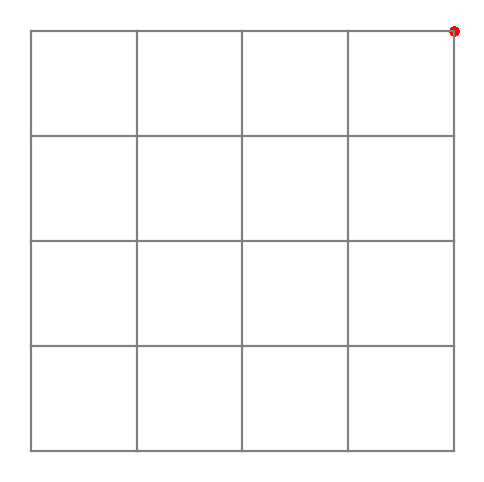

In [6]:
animate_events(network, events)